In [7]:
import numpy as np
import pandas as pd

import statsmodels.api as sm
from scipy.stats import ks_2samp, mannwhitneyu
from sklearn.metrics import average_precision_score

from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score, 
    precision_recall_curve,
    classification_report
)
pd.set_option("display.max_rows", None)
from statsmodels.tools.sm_exceptions import PerfectSeparationError

TARGET = "fraud"

%matplotlib inline

In [ ]:
df = pd.read_parquet("data")

In [9]:
df.head()

,id,fraud,log_abs_amount,amount_income_ratio,amount_limit_ratio,has_error,credit_limit,current_age,is_credit,has_chip,...,mcc_smoothed_risk_scaled_x_near_retirement,years_since_pin_change_x_client_merchant_new,risky_month_x_client_merchant_new,merchant_change_last5_x_amount_limit_ratio,risky_wdhour_x_client_mcc_new,client_error_last3_x_client_merchant_new,err_bad_cvv_x_client_merchant_new,limit_extreme_x_client_merchant_new,is_prepaid_x_client_merchant_new,refund_x_client_mcc_new
0,7487951,0,5.127647,0.002812,0.009524,0,17600.0,33,1,1,...,-0.0,0,0,0.009524,0,0,0,0,0,0
1,7516735,0,3.901366,0.000813,0.002754,0,17600.0,33,1,1,...,0.0,0,0,0.005508,0,0,0,0,0,0
2,7529000,0,4.743366,0.001909,0.006467,0,17600.0,33,1,1,...,-0.0,0,0,0.019401,0,0,0,0,0,0
3,7564511,0,5.026509,0.002540,0.008602,0,17600.0,33,1,1,...,0.0,0,0,0.034409,0,0,0,0,0,0
4,7630887,0,2.111425,0.000122,0.000413,0,17600.0,33,1,1,...,0.0,0,0,0.002063,0,0,0,0,0,0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 608430 entries, 0 to 608429
Data columns (total 64 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   id                                            608430 non-null  int64  
 1   fraud                                         608430 non-null  int8   
 2   log_abs_amount                                608430 non-null  float32
 3   amount_income_ratio                           608430 non-null  float32
 4   amount_limit_ratio                            608430 non-null  float32
 5   has_error                                     608430 non-null  int8   
 6   credit_limit                                  608430 non-null  float32
 7   current_age                                   608430 non-null  int64  
 8   is_credit                                     608430 non-null  int8   
 9   has_chip                                      60

In [11]:
# data
LABEL = "fraud"
IDCOL = "id"

assert LABEL in df.columns

X = df.drop(columns=[c for c in [LABEL] if c in df.columns]).copy()
y = df[LABEL].astype(int).copy()

# safe numeric (parquet/arrow friendly)
X = X.replace([np.inf, -np.inf], np.nan)
X = X.apply(pd.to_numeric, errors="coerce")

# fill (tree + NN 공통)
X = X.fillna(X.median(numeric_only=True))

In [12]:
# split
X_tr, X_va, y_tr, y_va = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### SHAP

TreeSHAP (TreeExplainer)\
→ LightGBM 같은 트리 기반 모델에 특화된 SHAP 알고리즘

| 종류                | 대상 모델                             | 특징                    |
| ----------------- | --------------------------------- | --------------------- |
| TreeExplainer     | LightGBM, XGBoost, RandomForest 등 | 트리 구조에 대해 정확한 SHAP 계산 |
| KernelExplainer   | 모든 모델                             | 모델 불문 사용 가능, 느림       |
| LinearExplainer   | 선형 모델                             | 선형 가정 기반              |
| DeepExplainer     | 딥러닝 모델                            | 특정 NN 구조에 최적화         |
| GradientExplainer | differentiable 모델                 | gradient 기반 근사        |


트리 모델에 대해 이론적으로 정확

계산 속도 우수

interaction 반영 가능

FDS 설명력 확보에 적합

In [13]:
import lightgbm as lgb
import shap

lgb_params = dict(
    objective="binary",
    learning_rate=0.05,
    num_leaves=64,
    min_data_in_leaf=200,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
)

dtr = lgb.Dataset(X_tr, label=y_tr, free_raw_data=False)
dva = lgb.Dataset(X_va, label=y_va, free_raw_data=False)

bst = lgb.train(
    lgb_params,
    dtr,
    valid_sets=[dva],
    num_boost_round=5000,
    callbacks=[lgb.early_stopping(200), lgb.log_evaluation(200)],
)

p_va = bst.predict(X_va)
print("PR-AUC:", average_precision_score(y_va, p_va))
print("ROC-AUC:", roc_auc_score(y_va, p_va))

[LightGBM] [Info] Number of positive: 5254, number of negative: 481490
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.092721 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3985
[LightGBM] [Info] Number of data points in the train set: 486744, number of used features: 61
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.010794 -> initscore=-4.517896
[LightGBM] [Info] Start training from score -4.517896
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 200 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Lig

/home/nakyung/.local/lib/python3.10/site-packages/shap/explainers/_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


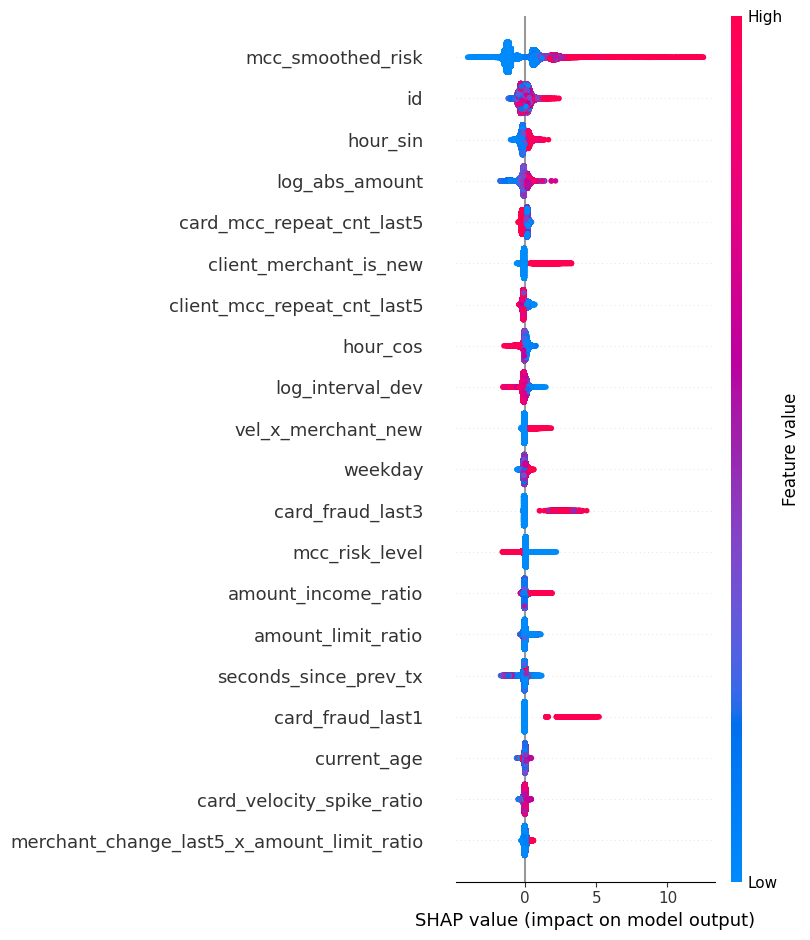

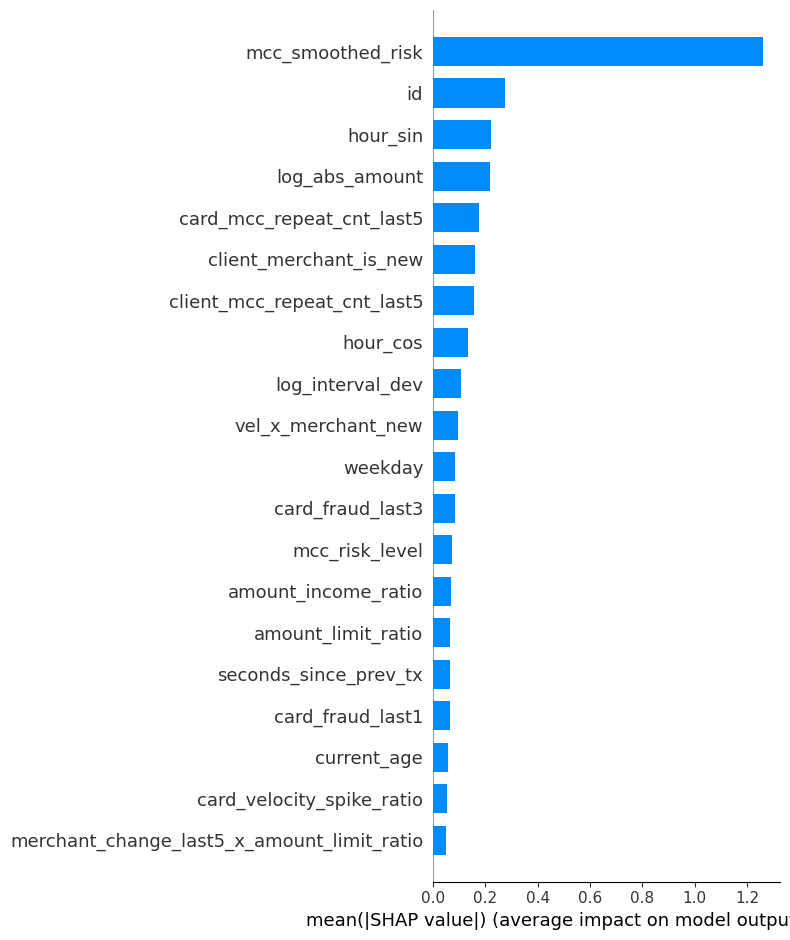

mcc_smoothed_risk                             1.262606
id                                            0.276265
hour_sin                                      0.219966
log_abs_amount                                0.218356
card_mcc_repeat_cnt_last5                     0.175789
client_merchant_is_new                        0.160212
client_mcc_repeat_cnt_last5                   0.157350
hour_cos                                      0.133985
log_interval_dev                              0.108191
vel_x_merchant_new                            0.095509
weekday                                       0.085080
card_fraud_last3                              0.083695
mcc_risk_level                                0.074036
amount_income_ratio                           0.068780
amount_limit_ratio                            0.066952
seconds_since_prev_tx                         0.066369
card_fraud_last1                              0.063574
current_age                                   0.056118
card_veloc

In [14]:
# SHAP
explainer = shap.TreeExplainer(bst)
shap_values = explainer.shap_values(X_va)

# global importance
shap.summary_plot(shap_values, X_va, show=True)
shap.summary_plot(shap_values, X_va, plot_type="bar", show=True)

# top-k feature list
mean_abs = np.abs(shap_values).mean(axis=0)
topk = pd.Series(mean_abs, index=X_va.columns).sort_values(ascending=False)
topk.head(30)

In [15]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"

In [16]:
class TabularDataset(Dataset):
    def __init__(self, X_df: pd.DataFrame, y_ser: pd.Series):
        self.X = torch.tensor(X_df.values, dtype=torch.float32)
        self.y = torch.tensor(y_ser.values, dtype=torch.float32)

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, i):
        return self.X[i], self.y[i]

In [17]:
class FeatureTokenTransformer(nn.Module):
    def __init__(self, n_features: int, d_model: int = 64, n_heads: int = 4, n_layers: int = 2, dropout: float = 0.1):
        super().__init__()
        self.n_features = n_features
        self.d_model = d_model

        # 각 feature 값을 token embedding으로 변환 (feature별 projection)
        self.feature_proj = nn.Parameter(torch.randn(n_features, d_model) * 0.02)
        self.feature_bias = nn.Parameter(torch.zeros(n_features, d_model))

        self.cls = nn.Parameter(torch.zeros(1, 1, d_model))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 1),
        )

    def forward(self, x):
        # x: (B, F)
        # token_i = x_i * W_i + b_i
        tok = x.unsqueeze(-1) * self.feature_proj.unsqueeze(0) + self.feature_bias.unsqueeze(0)  # (B, F, D)
        cls = self.cls.expand(x.size(0), 1, self.d_model)  # (B, 1, D)
        z = torch.cat([cls, tok], dim=1)  # (B, 1+F, D)
        z = self.encoder(z)              # (B, 1+F, D)
        logit = self.head(z[:, 0]).squeeze(-1)
        return logit

    @torch.no_grad()
    def attention_proxy(self):
        # feature-token 모델에서 feature별 중요도 proxy: |W_i| 평균
        w = self.feature_proj.detach().abs().mean(dim=1).cpu().numpy()
        return w

In [18]:
# loaders
bs = 4096
tr_ds = TabularDataset(X_tr, y_tr)
va_ds = TabularDataset(X_va, y_va)

tr_dl = DataLoader(tr_ds, batch_size=bs, shuffle=True, num_workers=0)
va_dl = DataLoader(va_ds, batch_size=bs, shuffle=False, num_workers=0)

model = FeatureTokenTransformer(n_features=X_tr.shape[1], d_model=64, n_heads=4, n_layers=2, dropout=0.1).to(device)

opt = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-2)
crit = nn.BCEWithLogitsLoss()

/home/nakyung/.local/lib/python3.10/site-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [19]:
def eval_nn(model, dl):
    model.eval()
    ys, ps = [], []
    for xb, yb in dl:
        xb = xb.to(device)
        yb = yb.to(device)
        logit = model(xb)
        prob = torch.sigmoid(logit)
        ys.append(yb.detach().cpu().numpy())
        ps.append(prob.detach().cpu().numpy())
    y_true = np.concatenate(ys)
    y_prob = np.concatenate(ps)
    return {
        "pr_auc": average_precision_score(y_true, y_prob),
        "roc_auc": roc_auc_score(y_true, y_prob),
    }

def train_nn(model, tr_dl, va_dl, epochs=10):
    best = -1.0
    best_state = None

    for ep in range(1, epochs + 1):
        model.train()
        for xb, yb in tr_dl:
            xb = xb.to(device)
            yb = yb.to(device)

            opt.zero_grad(set_to_none=True)
            logit = model(xb)
            loss = crit(logit, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

        m = eval_nn(model, va_dl)
        if m["pr_auc"] > best:
            best = m["pr_auc"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(f"epoch={ep} pr_auc={m['pr_auc']:.6f} roc_auc={m['roc_auc']:.6f}")

    if best_state is not None:
        model.load_state_dict(best_state)
    return model

model = train_nn(model, tr_dl, va_dl, epochs=10)
eval_nn(model, va_dl)

epoch=1 pr_auc=0.957190 roc_auc=0.996585
epoch=2 pr_auc=0.961711 roc_auc=0.996838
epoch=3 pr_auc=0.960856 roc_auc=0.996886
epoch=4 pr_auc=0.964828 roc_auc=0.997478
epoch=5 pr_auc=0.967317 roc_auc=0.997718
epoch=6 pr_auc=0.964522 roc_auc=0.997096
epoch=7 pr_auc=0.968222 roc_auc=0.997710
epoch=8 pr_auc=0.966755 roc_auc=0.997365
epoch=9 pr_auc=0.968443 roc_auc=0.997650
epoch=10 pr_auc=0.968977 roc_auc=0.998287


{'pr_auc': 0.968977066419954, 'roc_auc': 0.9982870326746092}

In [20]:
# attention-like importance (proxy)
att_proxy = model.attention_proxy()
att_rank = pd.Series(att_proxy, index=X_tr.columns).sort_values(ascending=False)
att_rank.head(30)

mcc_smoothed_risk                             0.208504
expire_high                                   0.067124
merchant_change_last5_x_amount_limit_ratio    0.065271
is_risky_wd_hour                              0.064993
is_risky_hour                                 0.064983
err_bad_cvv                                   0.062162
error_count                                   0.057250
has_error                                     0.054995
card_error_last3                              0.054942
limit_ratio_extreme                           0.051413
err_bad_cvv_x_client_merchant_new             0.048660
card_merchant_is_new                          0.048251
card_mcc_repeat_cnt_last5                     0.046943
limit_extreme_x_client_merchant_new           0.046689
vel_x_merchant_new                            0.046573
client_mcc_repeat_cnt_last5                   0.046347
client_error_last3                            0.045973
client_merchant_is_new                        0.045024
is_prepaid

### Ablation

In [21]:
def fit_lgb_eval(X_tr, y_tr, X_va, y_va, params=None, num_boost_round=3000, early_stopping=200):
    if params is None:
        params = lgb_params

    dtr = lgb.Dataset(X_tr, label=y_tr, free_raw_data=False)
    dva = lgb.Dataset(X_va, label=y_va, free_raw_data=False)

    bst = lgb.train(
        params,
        dtr,
        valid_sets=[dva],
        num_boost_round=num_boost_round,
        callbacks=[lgb.early_stopping(early_stopping), lgb.log_evaluation(-1)],
    )
    p = bst.predict(X_va)
    return average_precision_score(y_va, p), bst

base_pr, base_bst = fit_lgb_eval(X_tr, y_tr, X_va, y_va)
print("BASE PR-AUC:", base_pr)

[LightGBM] [Info] Number of positive: 5254, number of negative: 481490
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.020724 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3985
[LightGBM] [Info] Number of data points in the train set: 486744, number of used features: 61
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.010794 -> initscore=-4.517896
[LightGBM] [Info] Start training from score -4.517896
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 200 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Lig

In [22]:
def ablation_drop_one(X_tr, y_tr, X_va, y_va, base_pr, cols, top_k=None):
    cols = list(cols)
    if top_k is not None:
        cols = cols[:top_k]

    rows = []
    for c in cols:
        keep = [k for k in X_tr.columns if k != c]
        pr, _ = fit_lgb_eval(X_tr[keep], y_tr, X_va[keep], y_va)
        rows.append({"dropped": c, "PR_AUC": pr, "delta_vs_base": pr - base_pr})
    return pd.DataFrame(rows).sort_values("delta_vs_base")

shap_top = topk.index.tolist()
abl1 = ablation_drop_one(X_tr, y_tr, X_va, y_va, base_pr, shap_top, top_k=40)
abl1.head(30)

[LightGBM] [Info] Number of positive: 5254, number of negative: 481490
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017855 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3922
[LightGBM] [Info] Number of data points in the train set: 486744, number of used features: 60
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.010794 -> initscore=-4.517896
[LightGBM] [Info] Start training from score -4.517896
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[233]	valid_0's binary_logloss: 0.00486672
[LightGBM] [Info] Number of positive: 5254, number of negative: 481490
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018391 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[Lig

,dropped,PR_AUC,delta_vs_base
0,mcc_smoothed_risk,0.972942,-0.013158
1,id,0.980901,-0.005199
2,hour_sin,0.984007,-0.002093
3,log_abs_amount,0.984819,-0.001281
15,seconds_since_prev_tx,0.984932,-0.001168
34,client_mcc_is_new,0.985081,-0.001019
10,weekday,0.985086,-0.001014
23,month_sin,0.985137,-0.000963
37,client_error_last3,0.985181,-0.000920
4,card_mcc_repeat_cnt_last5,0.985345,-0.000755


In [23]:
def ablation_drop_group(X_tr, y_tr, X_va, y_va, base_pr, groups: dict):
    rows = []
    for g, gcols in groups.items():
        gcols = [c for c in gcols if c in X_tr.columns]
        keep = [c for c in X_tr.columns if c not in gcols]
        pr, _ = fit_lgb_eval(X_tr[keep], y_tr, X_va[keep], y_va)
        rows.append({"group": g, "n_drop": len(gcols), "PR_AUC": pr, "delta_vs_base": pr - base_pr})
    return pd.DataFrame(rows).sort_values("delta_vs_base")

GROUPS = {
    "velocity": [c for c in X.columns if c.startswith("vel_") or "velocity" in c],
    "mcc_risk": [c for c in X.columns if "mcc" in c and "risk" in c],
    "time": [c for c in X.columns if "hour" in c or "weekday" in c or "month" in c or "risky_" in c],
    "error": [c for c in X.columns if "error" in c or "err_" in c],
    "newness": [c for c in X.columns if "is_new" in c or "change_cnt" in c or "repeat_cnt" in c],
    "amount_limit": [c for c in X.columns if "amount" in c or "limit" in c or "refund" in c],
}

ablg = ablation_drop_group(X_tr, y_tr, X_va, y_va, base_pr, GROUPS)
ablg

[LightGBM] [Info] Number of positive: 5254, number of negative: 481490
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.020198 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2455
[LightGBM] [Info] Number of data points in the train set: 486744, number of used features: 55
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.010794 -> initscore=-4.517896
[LightGBM] [Info] Start training from score -4.517896
Training until validation scores don't improve for 200 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Early stopping, best iteration is:
[223]	valid_0's binary_logloss: 0.00304554
[LightGBM] [Info] Number of positive: 5254, number of negative: 481490
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testin

,group,n_drop,PR_AUC,delta_vs_base
1,mcc_risk,6,0.953360,-0.032741
5,amount_limit,9,0.981396,-0.004704
2,time,9,0.981403,-0.004698
4,newness,9,0.985325,-0.000775
3,error,7,0.986053,-0.000047
0,velocity,6,0.986794,0.000693


In [24]:
# outputs
out = {
    "lgb_base_pr_auc": float(base_pr),
    "shap_top30": topk.head(30),
    "attn_proxy_top30": att_rank.head(30),
    "ablation_drop_one": abl1,
    "ablation_drop_group": ablg,
}
out

{'lgb_base_pr_auc': 0.9861001411653618,
 'shap_top30': mcc_smoothed_risk                             1.262606
 id                                            0.276265
 hour_sin                                      0.219966
 log_abs_amount                                0.218356
 card_mcc_repeat_cnt_last5                     0.175789
 client_merchant_is_new                        0.160212
 client_mcc_repeat_cnt_last5                   0.157350
 hour_cos                                      0.133985
 log_interval_dev                              0.108191
 vel_x_merchant_new                            0.095509
 weekday                                       0.085080
 card_fraud_last3                              0.083695
 mcc_risk_level                                0.074036
 amount_income_ratio                           0.068780
 amount_limit_ratio                            0.066952
 seconds_since_prev_tx                         0.066369
 card_fraud_last1                              0.0

## 최종 Feature Selection 요약

### 1. 유지 (핵심 블록)

| Block          | Feature                                    |
| -------------- | ------------------------------------------ |
| Risk Core      | mcc_smoothed_risk                          |
|                | mcc_risk_level                             |
|                | mcc_smoothed_risk_scaled_x_is_prepaid      |
|                | mcc_smoothed_risk_scaled_x_near_retirement |
| Time           | hour_sin                                   |
|                | hour_cos                                   |
|                | weekday                                    |
|                | month_sin                                  |
|                | is_risky_wd_hour                           |
|                | is_risky_month                             |
| Amount / Limit | log_abs_amount                             |
|                | amount_income_ratio                        |
|                | amount_limit_ratio                         |
|                | limit_ratio_extreme                        |
|                | merchant_change_last5_x_amount_limit_ratio |
| Fraud History  | card_fraud_last1                           |
|                | card_fraud_last3                           |
|                | client_fraud_last3                         |
| Error          | client_error_last3                         |
|                | card_error_last3                           |
|                | err_bad_cvv                                |
|                | err_bad_cvv_x_client_merchant_new          |
| Newness        | client_merchant_is_new                     |
|                | client_mcc_is_new                          |
|                | card_merchant_is_new                       |
| Velocity (압축)  | vel_x_merchant_new                         |
|                | vel_x_mcc_risk                             |

---

### 2. 제거 권장

| Feature                   |
| ------------------------- |
| id                        |
| vel_x_card_mcc_new        |
| vel_x_client_mcc_new      |
| velocity_spike_ratio      |
| card_velocity_spike_ratio |
| card_mcc_change_cnt_last5 |
| expire_high               |
| is_credit                 |
| current_age               |

---

### 3. 블록별 유지 판단 근거

| Block        | Drop 영향       | 판단            |
| ------------ | ------------- | ------------- |
| mcc_risk     | -0.032 PR-AUC | 핵심            |
| amount_limit | -0.0047       | 유지            |
| time         | -0.0047       | 유지            |
| newness      | -0.0007       | 압축 유지         |
| error        | -0.00004      | 대표만 유지        |
| velocity     | +0.0007       | 과적합 가능, 축소 유지 |

---

### 최종 방향

* 총 약 25~30개 수준 유지
* Velocity 블록은 최소화
* MCC Risk 축은 유지
* id는 반드시 제거


In [27]:
# 제거 대상 컬럼 정의 (id는 유지, 모델 학습 시 drop)
DROP_COLS = [
    "vel_x_card_mcc_new",
    "vel_x_client_mcc_new",
    "velocity_spike_ratio",
    "card_velocity_spike_ratio",
    "card_mcc_change_cnt_last5",
    "expire_high",
    "is_credit",
    "current_age",
]

# 존재하는 컬럼만 제거
drop_existing = [c for c in DROP_COLS if c in df.columns]

df = df.drop(columns=drop_existing).copy()

# 중복 컬럼 최종 정리
df = df.loc[:, ~df.columns.duplicated()].copy()

# 확인
assert df.columns.duplicated().sum() == 0

# 최종 저장
df.to_parquet("DATA", index=False)